In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

In [10]:
senate_general_indiv = pd.read_csv("../../data/senate_general_indiv22.csv", dtype=str, parse_dates=["TRANSACTION_DT"])
senate_general_indiv20 = pd.read_csv("../../data/senate_general_indiv20.csv", dtype=str, parse_dates=["TRANSACTION_DT"])

## Summary statistics

In [11]:
# make transaction amount numeric
senate_general_indiv["TRANSACTION_AMT"] = senate_general_indiv["TRANSACTION_AMT"].astype(float)
senate_general_indiv20["TRANSACTION_AMT"] = senate_general_indiv20["TRANSACTION_AMT"].astype(float)

np.mean(senate_general_indiv["TRANSACTION_AMT"]).round(2), \
    np.quantile(senate_general_indiv["TRANSACTION_AMT"], [0.25, 0.5, 0.75]), \
    np.mean(senate_general_indiv20["TRANSACTION_AMT"]).round(2), \
    np.quantile(senate_general_indiv20["TRANSACTION_AMT"], [0.25, 0.5, 0.75])

(np.float64(131.96),
 array([ 11.,  25., 100.]),
 np.float64(171.43),
 array([ 25.,  50., 100.]))

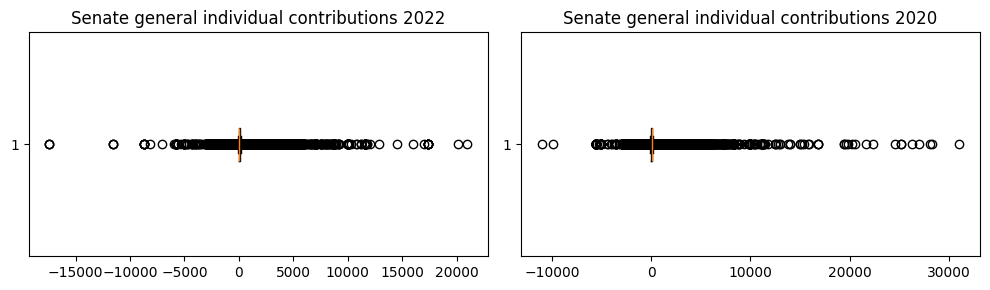

In [12]:
# create box plots for the two datasets
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.boxplot(senate_general_indiv["TRANSACTION_AMT"], vert=False)
plt.title("Senate general individual contributions 2022")
plt.subplot(1, 2, 2)
plt.boxplot(senate_general_indiv20["TRANSACTION_AMT"], vert=False)
plt.title("Senate general individual contributions 2020")
plt.tight_layout()
plt.show()

In [48]:
senate_general_indiv_trunc = senate_general_indiv[np.logical_and(senate_general_indiv["TRANSACTION_AMT"] > 0, senate_general_indiv["TRANSACTION_AMT"] < 2900)]
senate_general_indiv20_trunc = senate_general_indiv20[np.logical_and(senate_general_indiv20["TRANSACTION_AMT"] > 0, senate_general_indiv20["TRANSACTION_AMT"] < 2900)]

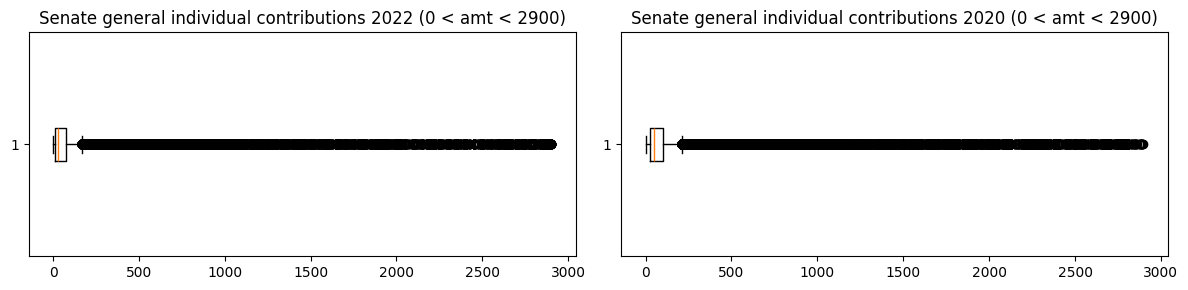

In [13]:
# same but constrained to contributions between 0 and 2900
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.boxplot(senate_general_indiv[np.logical_and(senate_general_indiv["TRANSACTION_AMT"] > 0, senate_general_indiv["TRANSACTION_AMT"] < 2900)]["TRANSACTION_AMT"], vert=False)
plt.title("Senate general individual contributions 2022 (0 < amt < 2900)")
plt.subplot(1, 2, 2)
plt.boxplot(senate_general_indiv20[np.logical_and(senate_general_indiv20["TRANSACTION_AMT"] > 0, senate_general_indiv20["TRANSACTION_AMT"] < 2900)]["TRANSACTION_AMT"], vert=False)
plt.title("Senate general individual contributions 2020 (0 < amt < 2900)")
plt.tight_layout()
plt.show()

In [14]:
np.sum(senate_general_indiv["TRANSACTION_AMT"] > 2900), \
    np.sum(senate_general_indiv20["TRANSACTION_AMT"] > 2900), \
    np.mean(senate_general_indiv["TRANSACTION_AMT"] > 2900), \
    np.mean(senate_general_indiv20["TRANSACTION_AMT"] > 2900)

(np.int64(1711),
 np.int64(2358),
 np.float64(0.0008480675361135012),
 np.float64(0.0010561166081726765))

In [15]:
mask = np.logical_and(senate_general_indiv["TRANSACTION_AMT"] > 0, 
                      senate_general_indiv["TRANSACTION_AMT"] < 200)
senate_general_indiv[mask]["TRANSACTION_AMT"].describe()

count    1.730173e+06
mean     3.516629e+01
std      3.290748e+01
min      1.000000e+00
25%      1.000000e+01
50%      2.500000e+01
75%      5.000000e+01
max      1.990000e+02
Name: TRANSACTION_AMT, dtype: float64

Text(0.5, 1.0, 'Distribution of Transaction Amounts (0 < amt < 200)')

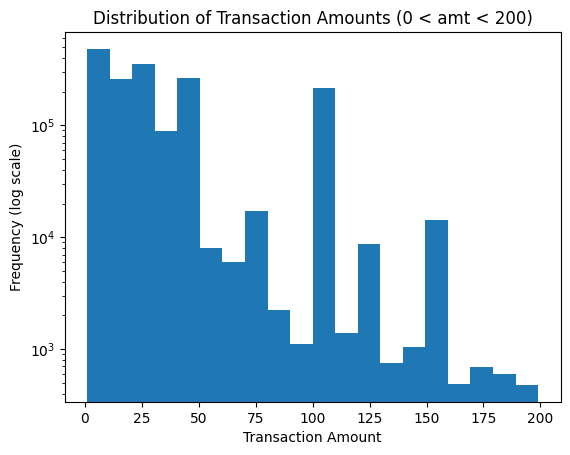

In [16]:
plt.hist(senate_general_indiv["TRANSACTION_AMT"][mask], bins=20)
plt.yscale("log")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Transaction Amounts (0 < amt < 200)")

## By zip code

In [17]:
# sum by zip code
senate_general_indiv['ZIP5'] = senate_general_indiv['ZIP_CODE'].astype(str).str[:5]
zip_sums = (
    senate_general_indiv
    .groupby('ZIP5', as_index=False)
    .agg({
        'TRANSACTION_AMT': 'sum',
        'STATE': 'first'   # take first state in each ZIP group
    })
)
zip_sums[zip_sums['ZIP5'].str.len() == 5].sort_values(by='TRANSACTION_AMT', ascending=False).head()

,ZIP5,TRANSACTION_AMT,STATE
8505,33480,1277901.0,FL
2201,10023,1199764.0,NY
2202,10024,1083050.0,NY
2199,10021,1021114.0,NY
5033,20815,898475.0,MD


In [60]:
senate_general_indiv.sort_values(by='TRANSACTION_AMT', ascending=False).head()

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST,ZIP5
978802,C00590489,202307159583508788,22Y,"LEVIN, DANIEL",NEW YORK,NY,100171863,NaN,NaN,2022-11-28,20918.0,S2FL00631,"DEMINGS, VAL",DEM,FL,10017
977905,C00787135,202307149582707507,22Y,"MCLAIN, RODNEY",GREENVILLE,SC,29605,NaN,NaN,2022-11-28,20090.0,S2NV00324,"LAXALT, ADAM",REP,NV,29605
1002899,C00795930,202306189582175897,15,"BREWER, FRANK",DOUGLASSVILLE,PA,195189716,NEXTGEN SECURED,CEO,2022-07-20,17400.0,S2PA00638,"OZ, MEHMET DR",REP,PA,19518
1931351,C00795930,202306209582217556,15E,"HOFFMAN, DIANA",SPARKS,NV,894347802,MUSIC WITH CONFIDENCE,PRESIDENT,2022-10-21,17400.0,S2PA00638,"OZ, MEHMET DR",REP,PA,89434
49401,C00608398,202210149532272712,22Y,"PLEKENPOL, LEROY W",HILTON HEAD ISLAND,SC,299262915,NaN,NaN,2022-09-20,17400.0,S4LA00065,"KENNEDY, JOHN NEELY",REP,LA,29926


In [61]:
# check for contributions from "BREWER, FRANK" in 2020 dataset
# just give contributor name, amoiunt, and who to, and date
senate_general_indiv[senate_general_indiv["NAME"] == "BREWER, FRANK"].sort_values(by="TRANSACTION_AMT", ascending=False).head()[["NAME", "TRANSACTION_AMT", "CAND_NAME", "TRANSACTION_DT"]]

,NAME,TRANSACTION_AMT,CAND_NAME,TRANSACTION_DT
1002899,"BREWER, FRANK",17400.0,"OZ, MEHMET DR",2022-07-20
1006658,"BREWER, FRANK",-2900.0,"OZ, MEHMET DR",2022-07-21
1006741,"BREWER, FRANK",-2900.0,"OZ, MEHMET DR",2022-07-21
1006657,"BREWER, FRANK",-8700.0,"OZ, MEHMET DR",2022-07-21


In [58]:
17400 - 2900 - 2900 - 8700

2900

In [51]:
senate_general_indiv.shape

(2017528, 16)

In [50]:
senate_general_indiv_trunc.shape

(1966181, 16)

In [49]:
senate_general_indiv_trunc['ZIP5'] = senate_general_indiv_trunc['ZIP_CODE'].astype(str).str[:5]
zip_sums_diff = (
    senate_general_indiv_trunc
    .groupby('ZIP5', as_index=False)
    .agg({
        'TRANSACTION_AMT': 'sum',
        'STATE': 'first'   # take first state in each ZIP group
    })
)
zip_sums_diff[zip_sums_diff['ZIP5'].str.len() == 5].sort_values(by='TRANSACTION_AMT', ascending=False).head()

,ZIP5,TRANSACTION_AMT,STATE
2186,10023,574830.0,NY
2187,10024,552000.0,NY
4827,20016,511860.0,DC
5000,20815,486925.0,MD
2188,10025,456120.0,NY


In [18]:
senate_general_indiv20['ZIP5'] = senate_general_indiv20['ZIP_CODE'].astype(str).str[:5]
zip_sums20 = senate_general_indiv20.groupby('ZIP5')['TRANSACTION_AMT'].sum().reset_index()
zip_sums20[zip_sums20['ZIP5'].str.len() == 5].sort_values(by='TRANSACTION_AMT', ascending=False).head()

,ZIP5,TRANSACTION_AMT
2528,10023,1748272.0
2529,10024,1693167.0
5199,20815,1414356.0
2526,10021,1286183.0
2527,10022,1259071.0


In [19]:
# differences in sums by zip code
zip_sums_diff = zip_sums.merge(zip_sums20, on='ZIP5', suffixes=('_22', '_20'))
zip_sums_diff['ABS_DIFF'] = np.abs(zip_sums_diff['TRANSACTION_AMT_22'] - zip_sums_diff['TRANSACTION_AMT_20'])
zip_sums_diff['REL_DIFF'] = (zip_sums_diff['TRANSACTION_AMT_22'] - zip_sums_diff['TRANSACTION_AMT_20']) / zip_sums_diff['TRANSACTION_AMT_20']
zip_sums_diff['REL_AB_DIFF'] = zip_sums_diff['ABS_DIFF'] / zip_sums_diff['TRANSACTION_AMT_20']
zip_sums_diff[zip_sums_diff['TRANSACTION_AMT_20'] > 100000].sort_values(by='REL_DIFF', ascending=False).head()

,ZIP5,TRANSACTION_AMT_22,STATE,TRANSACTION_AMT_20,ABS_DIFF,REL_DIFF,REL_AB_DIFF
9621,45202,241882.0,OH,101441.0,140441.0,1.384460,1.384460
9627,45208,258449.0,OH,118755.0,139694.0,1.176321,1.176321
7220,33037,222188.0,FL,107662.0,114526.0,1.063755,1.063755
17431,89135,252167.0,NV,130982.0,121185.0,0.925203,0.925203
9654,45243,439882.0,OH,234046.0,205836.0,0.879468,0.879468


Text(0, 0.5, 'Cumulative Density')

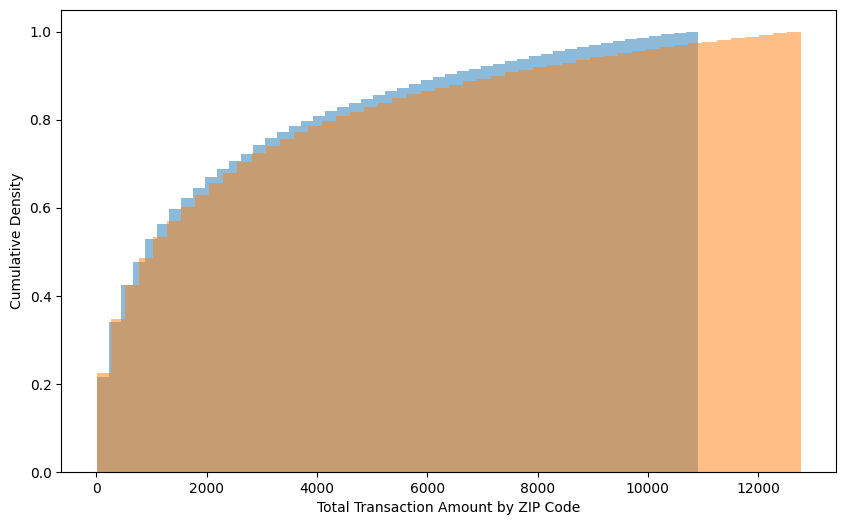

In [20]:
# CDF of zip sums in 2020 and 2022
zip_sums_trunc = zip_sums[np.logical_and(zip_sums['TRANSACTION_AMT'] < np.quantile(zip_sums['TRANSACTION_AMT'], 0.80),
                                         zip_sums['TRANSACTION_AMT'] > 0)]
zip_sums20_trunc = zip_sums20[np.logical_and(zip_sums20['TRANSACTION_AMT'] < np.quantile(zip_sums20['TRANSACTION_AMT'], 0.80),
                                              zip_sums20['TRANSACTION_AMT'] > 0)]

plt.figure(figsize=(10, 6))
plt.hist(zip_sums_trunc['TRANSACTION_AMT'], bins=50, density=True, cumulative=True, alpha=0.5, label='2022')
plt.hist(zip_sums20_trunc['TRANSACTION_AMT'], bins=50, density=True, cumulative=True, alpha=0.5, label='2020')
plt.xlabel('Total Transaction Amount by ZIP Code')
plt.ylabel('Cumulative Density')

## By state

In [21]:
# sum by zip code
state_sums22 = senate_general_indiv.groupby('STATE')['TRANSACTION_AMT'].sum().reset_index()
state_sums22.sort_values(by='TRANSACTION_AMT', ascending=False).head()

,STATE,TRANSACTION_AMT
7,CA,38390471.0
39,NY,22809065.0
12,FL,19443643.0
49,TX,13086039.0
54,WA,12817713.0


In [22]:
# sum by state for 2020 data
state_sums20 = senate_general_indiv20.groupby('STATE')['TRANSACTION_AMT'].sum().reset_index()
state_sums20.sort_values(by='TRANSACTION_AMT', ascending=False).head()

,STATE,TRANSACTION_AMT
7,CA,68305380.0
39,NY,31809380.0
49,TX,25131249.0
12,FL,21172643.0
23,MA,18016733.0


In [23]:
# difference in sums by state
state_sums_diff = state_sums22.merge(state_sums20, on='STATE', suffixes=('_22', '_20'))
state_sums_diff['ABS_DIFF'] = np.abs(state_sums_diff['TRANSACTION_AMT_22'] - state_sums_diff['TRANSACTION_AMT_20'])
state_sums_diff['REL_DIFF'] = (state_sums_diff['TRANSACTION_AMT_22'] - state_sums_diff['TRANSACTION_AMT_20']) / state_sums_diff['TRANSACTION_AMT_20'].replace(0, np.nan)
state_sums_diff['REL_AB_DIFF'] = np.abs(state_sums_diff['REL_DIFF'])
state_sums_diff['DIFF'] = state_sums_diff['TRANSACTION_AMT_22'] - state_sums_diff['TRANSACTION_AMT_20']
state_sums_diff.sort_values(by='ABS_DIFF', ascending=False).head()

,STATE,TRANSACTION_AMT_22,TRANSACTION_AMT_20,ABS_DIFF,REL_DIFF,REL_AB_DIFF,DIFF
7,CA,38390471.0,68305380.0,29914909.0,-0.437958,0.437958,-29914909.0
49,TX,13086039.0,25131249.0,12045210.0,-0.479292,0.479292,-12045210.0
39,NY,22809065.0,31809380.0,9000315.0,-0.282945,0.282945,-9000315.0
26,MI,3123133.0,12119855.0,8996722.0,-0.742313,0.742313,-8996722.0
23,MA,9182584.0,18016733.0,8834149.0,-0.490330,0.490330,-8834149.0


In [24]:
state_sums_diff.sort_values(by='REL_AB_DIFF', ascending=False).head()

,STATE,TRANSACTION_AMT_22,TRANSACTION_AMT_20,ABS_DIFF,REL_DIFF,REL_AB_DIFF,DIFF
50,UT,3289482.0,1616632.0,1672850.0,1.034775,1.034775,1672850.0
55,WI,5156460.0,2583494.0,2572966.0,0.995925,0.995925,2572966.0
0,AA,260.0,37845.0,37585.0,-0.993130,0.993130,-37585.0
14,GU,623.0,8719.0,8096.0,-0.928547,0.928547,-8096.0
31,MT,480010.0,3898351.0,3418341.0,-0.876868,0.876868,-3418341.0


## Distributions of contirbutions (individual, zip code, state)

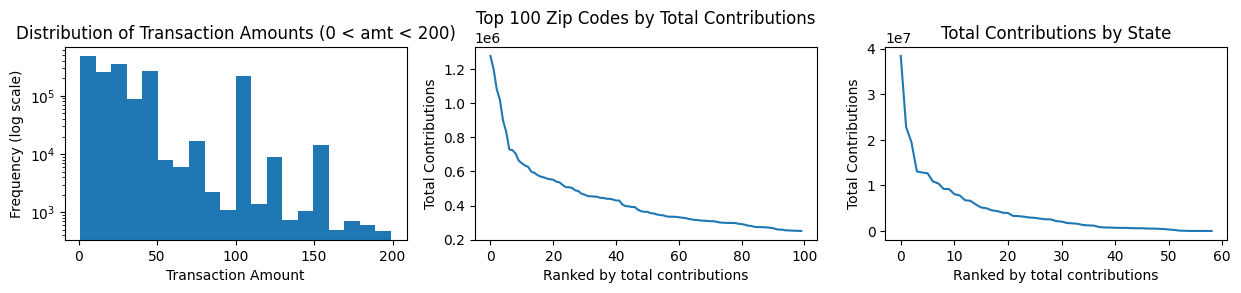

In [25]:
plt.figure(figsize=(15, 2.5))

plt.subplot(1, 3, 1)
plt.hist(senate_general_indiv["TRANSACTION_AMT"][mask], bins=20)
plt.yscale("log")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Transaction Amounts (0 < amt < 200)")

plt.subplot(1, 3, 2)
zip_sums_sorted = zip_sums[zip_sums['ZIP5'].str.len() == 5].sort_values(by='TRANSACTION_AMT', ascending=False)['TRANSACTION_AMT']
plt.plot(range(100),zip_sums_sorted[:100])
plt.xlabel('Ranked by total contributions')
plt.ylabel('Total Contributions')
plt.title('Top 100 Zip Codes by Total Contributions')

plt.subplot(1, 3, 3)
state_sums_sorted = state_sums22.sort_values(by='TRANSACTION_AMT', ascending=False)['TRANSACTION_AMT']
plt.plot(range(len(state_sums_sorted)), state_sums_sorted)
plt.xlabel('Ranked by total contributions')
plt.ylabel('Total Contributions')
plt.title('Total Contributions by State')

plt.savefig("figures/transaction_amount_distribution.png", bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Top 100 Zip Codes by Total Contributions')

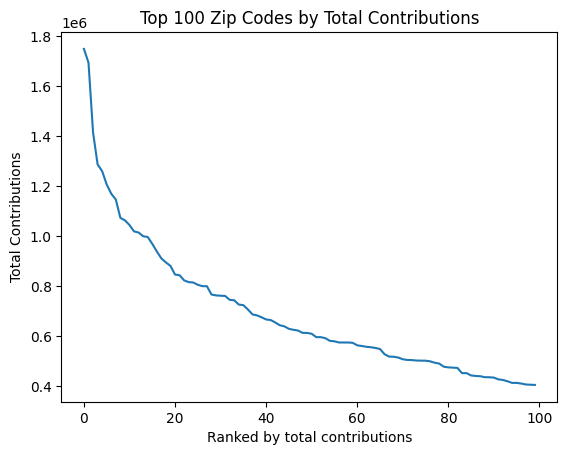

In [26]:
zip_sums_sorted20 = zip_sums20[zip_sums20['ZIP5'].str.len() == 5].sort_values(by='TRANSACTION_AMT', ascending=False)['TRANSACTION_AMT']
plt.plot(range(100),zip_sums_sorted20[:100])
plt.xlabel('Ranked by total contributions')
plt.ylabel('Total Contributions')
plt.title('Top 100 Zip Codes by Total Contributions')

## Geospatial plots

In [27]:
url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_20m.zip"
states = gpd.read_file(url)

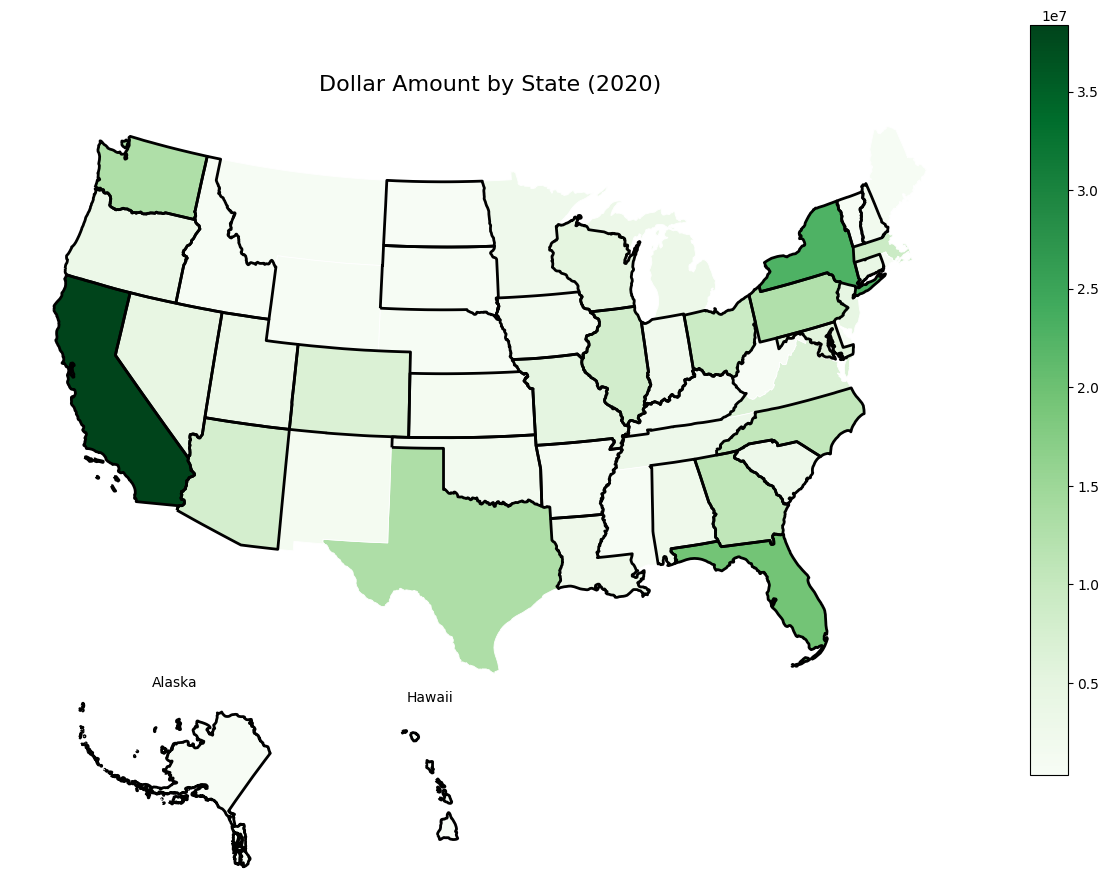

In [28]:
election_states22 = [
    "AL","AK","AZ","AR","CA","CO","CT","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","MD","MO","NV","NH","NY","NC","ND","OH","OK","OR","PA",
    "SC","SD","UT","VT","WA","WI"
]

url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_20m.zip"
states = gpd.read_file(url)

exclude = ["PR", "VI", "GU", "MP", "AS"]
states = states[~states["STUSPS"].isin(exclude)].copy()

states = states.merge(
    state_sums22,
    how="left",
    left_on="STUSPS",
    right_on="STATE"
)

states["highlight"] = states["STUSPS"].isin(election_states22)
states = states.to_crs("EPSG:2163")

# Split into mainland / AK / HI
mainland = states[~states["STUSPS"].isin(["AK", "HI"])].copy()
alaska = states[states["STUSPS"] == "AK"].copy()
hawaii = states[states["STUSPS"] == "HI"].copy()

fig = plt.figure(figsize=(15, 10))

# Main map
ax_main = fig.add_axes([0.05, 0.15, 0.8, 0.75])

mainland.plot(
    column="TRANSACTION_AMT",
    ax=ax_main,
    legend=True,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6,
        "label": "No data"
    }
)

mainland[mainland["highlight"]].boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=2
)

ax_main.set_title("Dollar Amount by State (2020)", fontsize=16)
ax_main.set_axis_off()

# Alaska inset
ax_ak = fig.add_axes([0.07, 0.05, 0.18, 0.18])
alaska.plot(
    column="TRANSACTION_AMT",
    ax=ax_ak,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
alaska[alaska["highlight"]].boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=2.0
)
ax_ak.set_axis_off()
ax_ak.set_title("Alaska", fontsize=10)

# Hawaii inset
ax_hi = fig.add_axes([0.27, 0.08, 0.12, 0.12])
hawaii.plot(
    column="TRANSACTION_AMT",
    ax=ax_hi,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
hawaii[hawaii["highlight"]].boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=2.0
)
ax_hi.set_axis_off()
ax_hi.set_title("Hawaii", fontsize=10)

plt.show()

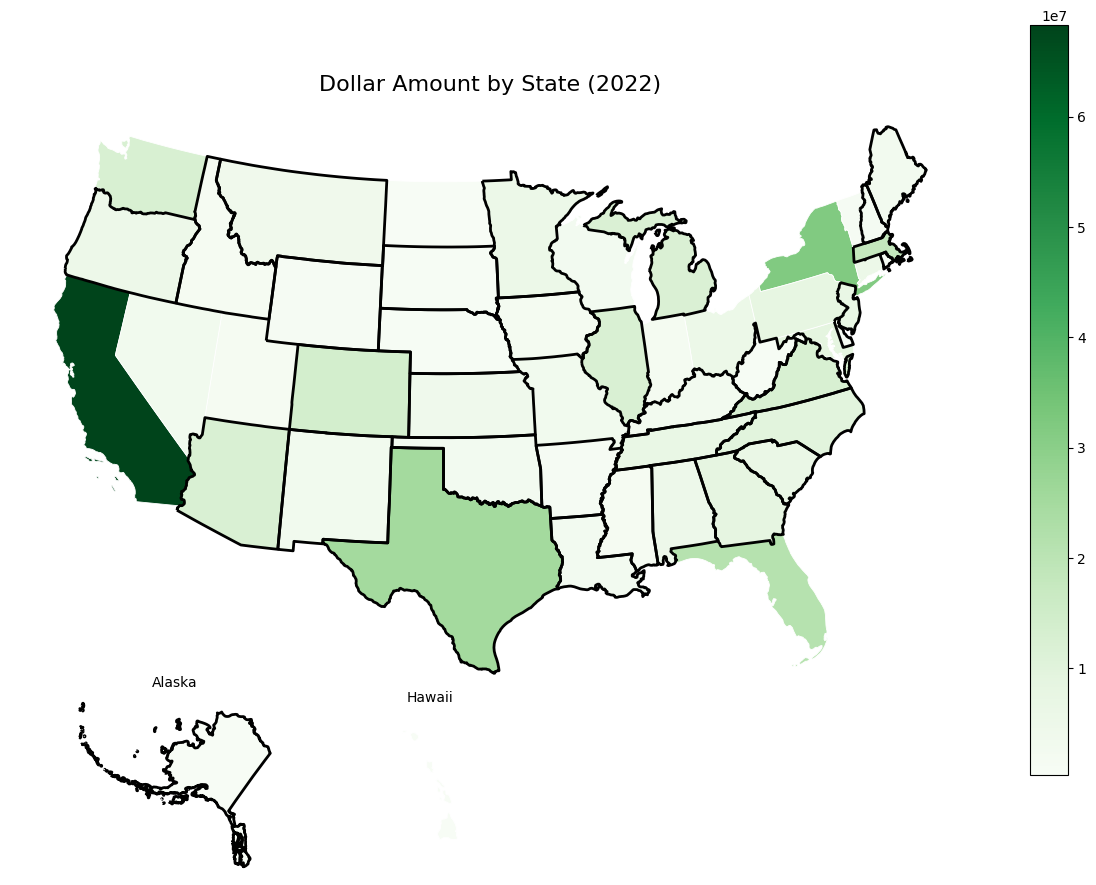

In [46]:
election_states20 = [
    "AL", "AK", "AZ", "AR", "CO", "DE", "GA", "ID", "IL", "IA",
    "KS", "KY", "LA", "ME", "MA", "MI", "MN", "MS", "MT", "NE",
    "NH", "NJ", "NM", "NC", "OK", "OR", "RI", "SC", "SD", "TN",
    "TX", "VA", "WV", "WY"
]

url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_20m.zip"
states = gpd.read_file(url)

exclude = ["PR", "VI", "GU", "MP", "AS"]
states = states[~states["STUSPS"].isin(exclude)].copy()

states = states.merge(
    state_sums20,
    how="left",
    left_on="STUSPS",
    right_on="STATE"
)

states["highlight"] = states["STUSPS"].isin(election_states20)
states = states.to_crs("EPSG:2163")

# Split into mainland / AK / HI
mainland = states[~states["STUSPS"].isin(["AK", "HI"])].copy()
alaska = states[states["STUSPS"] == "AK"].copy()
hawaii = states[states["STUSPS"] == "HI"].copy()

fig = plt.figure(figsize=(15, 10))

# Main map
ax_main = fig.add_axes([0.05, 0.15, 0.8, 0.75])

mainland.plot(
    column="TRANSACTION_AMT",
    ax=ax_main,
    legend=True,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6,
        "label": "No data"
    }
)

mainland[mainland["highlight"]].boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=2
)

ax_main.set_title("Dollar Amount by State (2022)", fontsize=16)
ax_main.set_axis_off()

# Alaska inset
ax_ak = fig.add_axes([0.07, 0.05, 0.18, 0.18])
alaska.plot(
    column="TRANSACTION_AMT",
    ax=ax_ak,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
alaska[alaska["highlight"]].boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=2.0
)
ax_ak.set_axis_off()
ax_ak.set_title("Alaska", fontsize=10)

# Hawaii inset
ax_hi = fig.add_axes([0.27, 0.08, 0.12, 0.12])
hawaii.plot(
    column="TRANSACTION_AMT",
    ax=ax_hi,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
ax_hi.set_axis_off()
ax_hi.set_title("Hawaii", fontsize=10)

plt.show()

In [30]:
one_or = list(set(election_states20) ^ set(election_states22))
# is AK and HI in one_or 
print("AK in one_or:", "AK" in one_or)
print("HI in one_or:", "HI" in one_or)


AK in one_or: False
HI in one_or: True


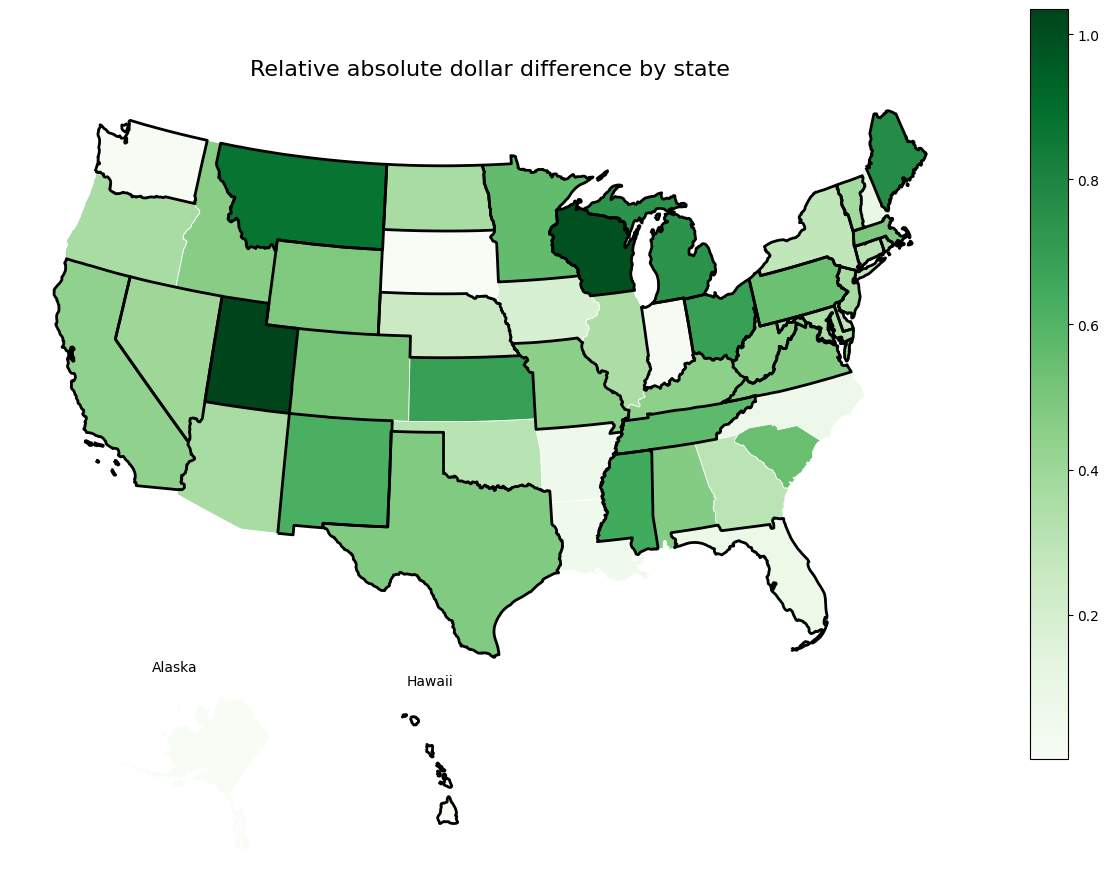

In [31]:

url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_20m.zip"
states = gpd.read_file(url)

exclude = ["PR", "VI", "GU", "MP", "AS"]
states = states[~states["STUSPS"].isin(exclude)].copy()

states = states.merge(
    state_sums_diff[["STATE", "REL_AB_DIFF"]],
    how="left",
    left_on="STUSPS",
    right_on="STATE"
)

states["highlight"] = states["STUSPS"].isin(one_or)
states = states.to_crs("EPSG:2163")

# Split into mainland / AK / HI
mainland = states[~states["STUSPS"].isin(["AK", "HI"])].copy()
alaska = states[states["STUSPS"] == "AK"].copy()
hawaii = states[states["STUSPS"] == "HI"].copy()

fig = plt.figure(figsize=(15, 10))

# Main map
ax_main = fig.add_axes([0.05, 0.15, 0.8, 0.75])

mainland.plot(
    column="REL_AB_DIFF",
    ax=ax_main,
    legend=True,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6,
        "label": "No data"
    }
)

mainland[mainland["highlight"]].boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=2
)

ax_main.set_title("Relative absolute dollar difference by state", fontsize=16)
ax_main.set_axis_off()

# Alaska inset
ax_ak = fig.add_axes([0.07, 0.05, 0.18, 0.18])
alaska.plot(
    column="REL_AB_DIFF",
    ax=ax_ak,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
ax_ak.set_axis_off()
ax_ak.set_title("Alaska", fontsize=10)

# Hawaii inset
ax_hi = fig.add_axes([0.27, 0.08, 0.12, 0.12])
hawaii.plot(
    column="REL_AB_DIFF",
    ax=ax_hi,
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "linewidth": 0.6
    }
)
hawaii[hawaii["highlight"]].boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=2.0
)
ax_hi.set_axis_off()
ax_hi.set_title("Hawaii", fontsize=10)

plt.show()

## Race results

In [32]:
results = pd.read_csv("../../data/senate_margin_of_victory_2020_2022.csv")

In [33]:
# min margin of victory between 2020 and 2022
min_margin = results.groupby("state")["margin_of_victory_pp"].min()

state_sums_diff_margin = state_sums_diff.merge(min_margin, left_on="STATE", 
                                               right_on="state", how="left")
state_sums_diff_margin = state_sums_diff_margin.dropna(subset=["margin_of_victory_pp"])
zip_sums_diff_margin = zip_sums_diff.merge(min_margin, left_on="STATE",
                                           right_on="state", how="left")
zip_sums_diff_margin = zip_sums_diff_margin.dropna(subset=["margin_of_victory_pp"])

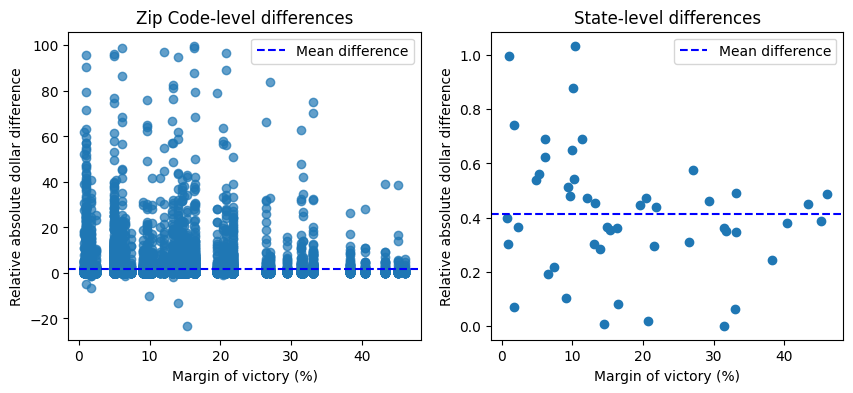

In [47]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.plot(state_sums_diff_margin["margin_of_victory_pp"], state_sums_diff_margin["REL_AB_DIFF"], "o")
plt.xlabel("Margin of victory (%)")
plt.ylabel("Relative absolute dollar difference")
plt.axhline(np.mean(state_sums_diff_margin["REL_AB_DIFF"]), color="blue", linestyle="--", 
            label="Mean difference")
plt.title("State-level differences")
plt.legend()

zip_sums_diff_margin_trunc = zip_sums_diff_margin[zip_sums_diff_margin["REL_AB_DIFF"] < 100]
plt.subplot(1, 2, 1)
plt.plot(zip_sums_diff_margin_trunc["margin_of_victory_pp"], 
         zip_sums_diff_margin_trunc["REL_AB_DIFF"], "o", alpha=0.7)
plt.xlabel("Margin of victory (%)")
plt.ylabel("Relative absolute dollar difference")
plt.axhline(np.mean(zip_sums_diff_margin_trunc["REL_AB_DIFF"]), color="blue", linestyle="--", label="Mean difference")
plt.title("Zip Code-level differences")
plt.legend()

plt.savefig("figures/margin_vs_diff.png", bbox_inches='tight')
plt.show()

## Zip code choropleth, in Washington

In [35]:
zip_sums_diff_wa = zip_sums_diff[zip_sums_diff["STATE"] == "WA"].copy()

In [36]:
zip_sums_diff_wa

,ZIP5,TRANSACTION_AMT_22,STATE,TRANSACTION_AMT_20,ABS_DIFF,REL_DIFF,REL_AB_DIFF
19567,97908,80.0,WA,100.0,20.0,-0.200000,0.200000
19570,98001,34879.0,WA,12551.0,22328.0,1.778982,1.778982
19571,98002,5995.0,WA,4542.0,1453.0,0.319903,0.319903
19572,98003,18604.0,WA,20219.0,1615.0,-0.079875,0.079875
19573,98004,309638.0,WA,305383.0,4255.0,0.013933,0.013933
...,...,...,...,...,...,...,...
20072,99360,1229.0,WA,1450.0,221.0,-0.152414,0.152414
20073,99362,88873.0,WA,35762.0,53111.0,1.485124,1.485124
20074,99363,210.0,WA,225.0,15.0,-0.066667,0.066667
20075,99402,6576.0,WA,4000.0,2576.0,0.644000,0.644000


In [37]:
zctas = gpd.read_file("../../data/tl_2020_us_zcta520.shp")

# Filter WA ZIP prefixes
wa_zctas = zctas[zctas["ZCTA5CE20"].str.startswith(("98", "99"))].copy()
wa_map = wa_zctas.merge(
    zip_sums_diff_wa,
    left_on="ZCTA5CE20",
    right_on="ZIP5",
    how="left"
)
wa_map = wa_map[wa_map["TRANSACTION_AMT_22"].notna()].copy()

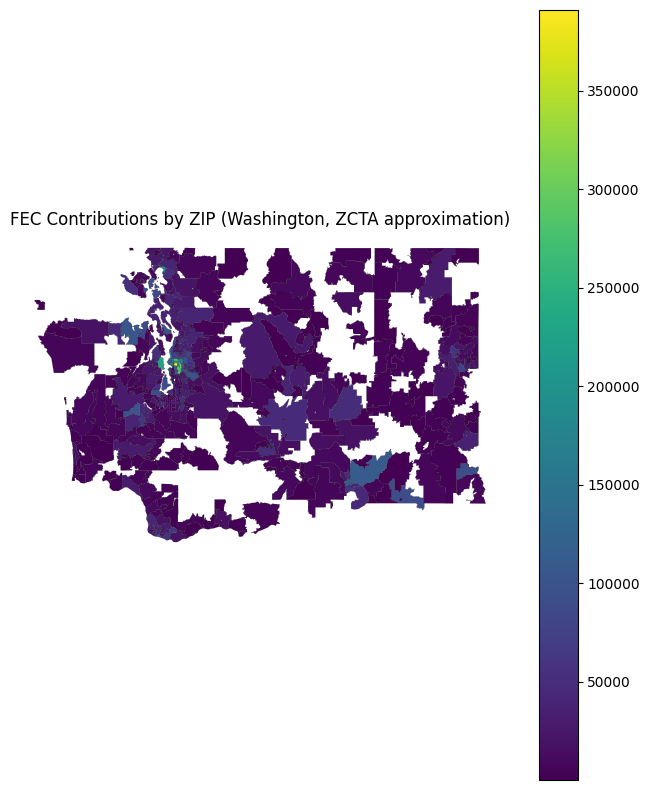

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

wa_map.plot(
    column="TRANSACTION_AMT_22",          # use log scale
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title("FEC Contributions by ZIP (Washington, ZCTA approximation)")
ax.axis("off")

plt.show()

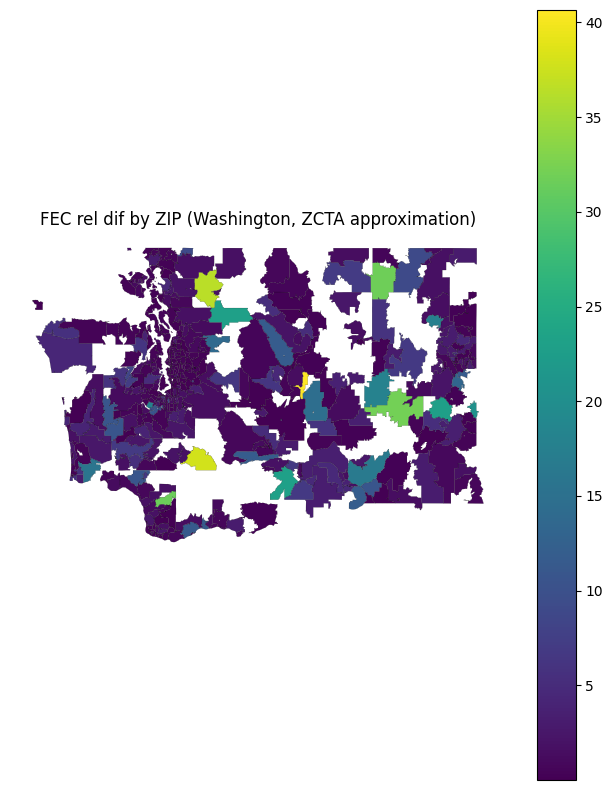

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

wa_map.plot(
    column="REL_AB_DIFF",         
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title("FEC rel dif by ZIP (Washington, ZCTA approximation)")
ax.axis("off")

plt.show()

In [40]:
# zips, all starting with 48
zip_sums_diff_start4 = zip_sums_diff[zip_sums_diff["ZIP5"].str.startswith("48")].copy()
start4_zctas = zctas[zctas["ZCTA5CE20"].str.startswith("48")].copy()
start4_map = start4_zctas.merge(
    zip_sums_diff_start4,
    left_on="ZCTA5CE20",
    right_on="ZIP5",
    how="left"
)
start4_map = start4_map[start4_map["TRANSACTION_AMT_22"].notna()].copy()

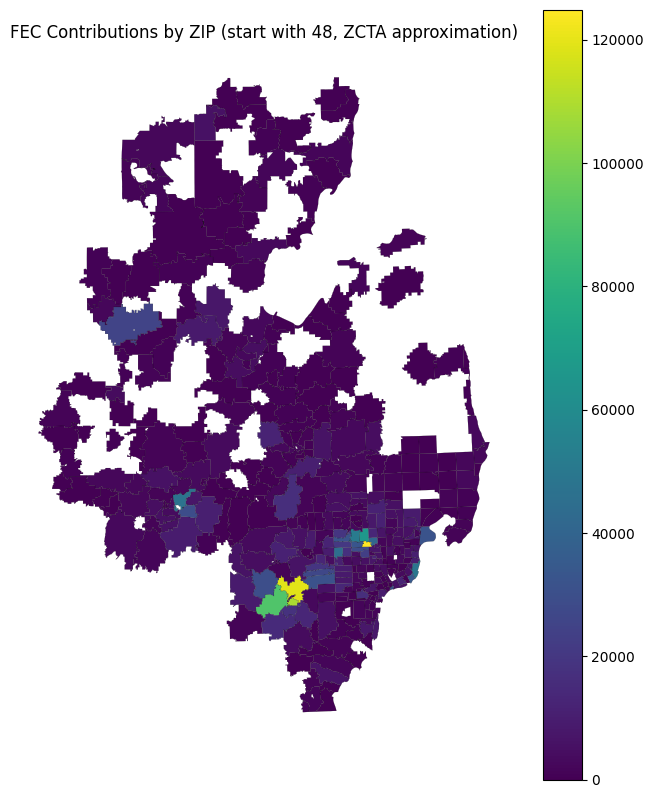

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

start4_map.plot(
    column="TRANSACTION_AMT_22",          # use log scale
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title("FEC Contributions by ZIP (start with 48, ZCTA approximation)")
ax.axis("off")

plt.show()

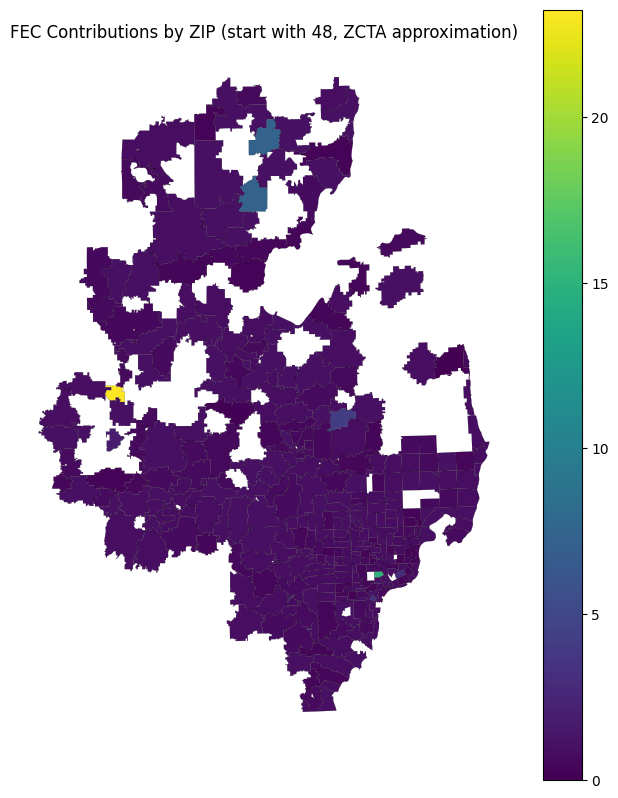

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

start4_map.plot(
    column="REL_AB_DIFF",          # use log scale
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title("FEC Contributions by ZIP (start with 48, ZCTA approximation)")
ax.axis("off")

plt.show()

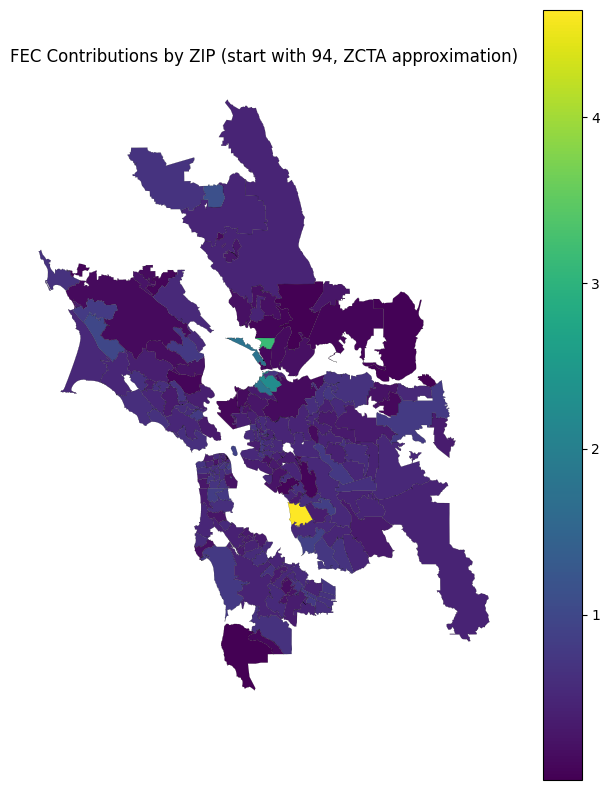

In [43]:
# zips, all starting with 94
zip_sums_diff_start4 = zip_sums_diff[zip_sums_diff["ZIP5"].str.startswith("94")].copy()
start4_zctas = zctas[zctas["ZCTA5CE20"].str.startswith("94")].copy()
start4_map = start4_zctas.merge(
    zip_sums_diff_start4,
    left_on="ZCTA5CE20",
    right_on="ZIP5",
    how="left"
)
start4_map = start4_map[start4_map["TRANSACTION_AMT_22"].notna()].copy()

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

start4_map.plot(
    column="REL_AB_DIFF",          # use log scale
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title("FEC Contributions by ZIP (start with 94, ZCTA approximation)")
ax.axis("off")

plt.show()

(array([2974., 1362., 1358., 1993., 1666., 1764., 2998.,    0., 1034.,
        1701.,    0.,  639.,  135.,  522.,  768.,    0.,  149.,  161.,
         135.,  153.]),
 array([ 0.77660773,  3.04224492,  5.30788211,  7.57351931,  9.8391565 ,
        12.10479369, 14.37043088, 16.63606808, 18.90170527, 21.16734246,
        23.43297965, 25.69861685, 27.96425404, 30.22989123, 32.49552842,
        34.76116562, 37.02680281, 39.29244   , 41.55807719, 43.82371439,
        46.08935158]),
 <BarContainer object of 20 artists>)

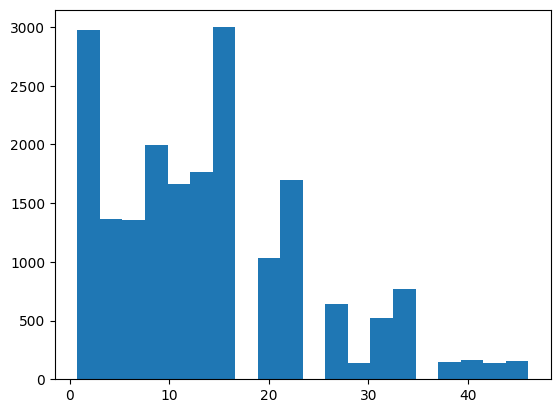

In [44]:
plt.hist(zip_sums_diff_margin["margin_of_victory_pp"], bins=20)

(array([6964., 8361.,  895.,  558.,  432.,  312.,  257.,  145.,  162.,
         120.,  119.,   83.,   69.,   67.,   65.,   45.,   51.,   31.,
          55.,   32.]),
 array([0.        , 0.49878049, 0.99756098, 1.49634146, 1.99512195,
        2.49390244, 2.99268293, 3.49146341, 3.9902439 , 4.48902439,
        4.98780488, 5.48658537, 5.98536585, 6.48414634, 6.98292683,
        7.48170732, 7.9804878 , 8.47926829, 8.97804878, 9.47682927,
        9.97560976]),
 <BarContainer object of 20 artists>)

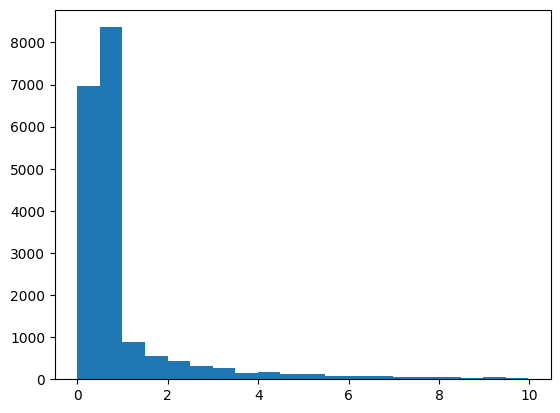

In [45]:
ab_diffs = zip_sums_diff_margin["REL_AB_DIFF"]
plt.hist(ab_diffs[np.logical_and(ab_diffs < 10, ab_diffs > -1)], bins=20)

## 